In [1]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    roc_auc_score, average_precision_score,
    brier_score_loss
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings('ignore')


# ── Metric helpers (binary + multiclass safe) ────────────────────────────────

def safe_roc_auc(y_true, y_proba):
    """
    ROC-AUC that works for both binary and multiclass.
    Binary     → pass only the positive-class column (sklearn requirement).
    Multiclass → OvR macro average.
    """
    classes = np.unique(y_true)
    if len(classes) == 2:
        return roc_auc_score(y_true, y_proba[:, 1])
    return roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')


def multiclass_pr_auc(y_true, y_proba):
    """Macro-averaged PR-AUC via one-vs-rest."""
    classes = np.unique(y_true)
    y_bin   = label_binarize(y_true, classes=classes)
    if y_bin.shape[1] == 1:          # binary edge-case from label_binarize
        y_bin = np.hstack([1 - y_bin, y_bin])
    scores = [
        average_precision_score(y_bin[:, c], y_proba[:, c])
        for c in range(len(classes))
        if c < y_proba.shape[1]
    ]
    return float(np.mean(scores)) if scores else float('nan')


def multiclass_brier_score(y_true, y_proba):
    """Multiclass Brier score via one-vs-rest macro average."""

    y_proba = np.clip(y_proba, 0, 1)

    classes = np.unique(y_true)
    y_bin   = label_binarize(y_true, classes=classes)
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])
    scores = [
        brier_score_loss(y_bin[:, c], y_proba[:, c])
        for c in range(len(classes))
        if c < y_proba.shape[1]
    ]
    return float(np.mean(scores)) if scores else float('nan')


def expected_calibration_error(y_true, y_proba, n_bins=10):
    """
    Multiclass ECE via one-vs-rest decomposition.
    Buckets predicted probabilities into equal-width bins and computes
    |accuracy - confidence| weighted by bin fraction, averaged across classes.
    """
    classes   = np.unique(y_true)
    y_bin     = label_binarize(y_true, classes=classes)
    if y_bin.shape[1] == 1:
        y_bin = np.hstack([1 - y_bin, y_bin])
    bins      = np.linspace(0, 1, n_bins + 1)
    ece_vals  = []
    for c in range(len(classes)):
        if c >= y_proba.shape[1]:
            continue
        prob_c = y_proba[:, c]
        true_c = y_bin[:, c]
        ece_c  = 0.0
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (prob_c >= lo) & (prob_c < hi)
            if mask.sum() == 0:
                continue
            ece_c += (mask.sum() / len(y_true)) * abs(true_c[mask].mean() - prob_c[mask].mean())
        ece_vals.append(ece_c)
    return float(np.mean(ece_vals)) if ece_vals else float('nan')

def ci_95(series):
    """
    95% confidence interval for the mean of a pandas Series or 1-D array,
    using the t-distribution (appropriate for small simulation counts).
    Returns (lower, upper).
    """
    from scipy.stats import t as t_dist
    n    = len(series)
    mean = np.mean(series)
    se   = np.std(series, ddof=1) / np.sqrt(n)
    h    = t_dist.ppf(0.975, df=n - 1) * se   # half-width
    return mean - h, mean + h


In [2]:
# (Metric helpers are defined in Cell 0 above.)


In [3]:
# %%
# ─────────────────────────────────────────────────────────────────────────────
# Theoretical Risk Functions  (Cover & Hart 1967 / Dist-KNN framework)
# ─────────────────────────────────────────────────────────────────────────────

def compute_r_star_x(model, X_query: pd.DataFrame) -> np.ndarray:
    """
    Conditional Bayes risk r*(x) at each query point x.

    For an M-class problem:
        r*(x) = 1 - max_c { q̂_c(x) }

    i.e. 1 minus the highest posterior class probability.
    This equals min(q̂₁, q̂₂) in the binary case.

    Parameters
    ----------
    model     : fitted GridSearchCV wrapping a KNeighborsClassifier (dictionary containing dist and prob model)
    X_query   : query points  (n_samples × n_features)

    Returns
    -------
    r_star : ndarray of shape (n_samples,)
    """
    prob_model = model['prob_model']
    q_hat = prob_model.predict_proba(X_query)          # (n_samples, n_classes)
    r_star = 1.0 - q_hat.max(axis=1)              # scalar per query point
    return r_star


def compute_R_star(model, X_query: pd.DataFrame) -> float:
    """
    Expected Bayes risk R* = E[r*(x)] for one machine,
    approximated by the sample mean over X_query.

    Parameters
    ----------
    model     : fitted GridSearchCV
    X_query   : held-out query points

    Returns
    -------
    R_star : float
    """
    return float(compute_r_star_x(model, X_query).mean())


def compute_mu_hat(model, X: pd.DataFrame) -> np.ndarray:
    """
    Proxy for μ(x): the model's predicted class probability vector at each point.
    Works for any number of classes — returns the full (n_samples, n_classes) matrix
    so that bias can be computed per class and then averaged into a scalar norm.

    Parameters
    ----------
    model : fitted GridSearchCV (dictionary for prob_model and dist_model)
    X     : feature matrix

    Returns
    -------
    mu_hat : ndarray of shape (n_samples, n_classes)
    """
    prob_model = model['prob_model']
    return prob_model.predict_proba(X)   # (n_samples, n_classes)


def compute_bias_vector(
    model,
    X_query: pd.DataFrame,
    K_i: int,
) -> np.ndarray:
    """
    Local bias for machine i, generalised to any number of classes:
        Bᵢ(x) = ‖μ(x) - (1/Kᵢ) Σⱼ μ(xᵢ,ⱼ)‖₂

    μ(x) is the full predicted class-probability vector (n_classes,).
    The per-class difference is averaged across classes via the L2 norm
    to produce a single scalar bias per query point, which is what the
    Dist-KNN covariance matrix C requires.

    Parameters
    ----------
    model   : fitted GridSearchCV (KNN inside)
    X_query : query points  (n_samples × n_features)
    K_i     : number of neighbours used by this machine

    Returns
    -------
    B_i : ndarray of shape (n_samples,)  — one scalar bias per query point
    """
    dist_model = model['dist_model']
    knn: KNeighborsClassifier = dist_model.best_estimator_

    # μ(x) — full probability vector at each query point: (n_samples, n_classes)
    mu_x = compute_mu_hat(model, X_query)

    # Retrieve the K_i nearest training-set neighbours for each query point
    distances, indices = knn.kneighbors(X_query, n_neighbors=K_i)

    # μ̂ at every training point: (n_train, n_classes)
    X_train_arr = knn._fit_X
    X_train_df  = pd.DataFrame(X_train_arr, columns=X_query.columns)
    mu_train    = compute_mu_hat(model, X_train_df)   # (n_train, n_classes)

    # Average μ over the K_i neighbours: indices is (n_samples, K_i)
    # mu_train[indices] → (n_samples, K_i, n_classes)
    mu_neighbour_means = mu_train[indices].mean(axis=1)  # (n_samples, n_classes)

    # Per-class difference, collapsed to a scalar via L2 norm — works for any n_classes
    B_i = np.linalg.norm(mu_x - mu_neighbour_means, axis=1)  # (n_samples,)
    return B_i


print("Theoretical risk functions defined.")

Theoretical risk functions defined.


In [4]:
def create_models(server_datasets):

    best_neighbors = []
    best_f1_scores = []
    model_instance_list = []
    dataset_sizes = []
        
    for df_train, df_test in (server_datasets):
        params1 = {"n_neighbors": np.arange(3, 51, 2)}
        knn = KNeighborsClassifier()
        model1 = GridSearchCV(knn, params1, scoring='f1_macro', cv=2, n_jobs=-1)
        # params2 = {"n_estimators": np.array([50, 100, 150, 200]), "max_depth": np.array([3, 5, 8, 10, 15])}
        # random_forests = RandomForestClassifier()
        # model2 = GridSearchCV(random_forests, params2, scoring='f1_macro', cv=2, n_jobs=-1)
        
        X_s_train = df_train.drop(['y'], axis=1).values
        y_s_train = df_train['y'].values
        X_s_test = df_test.drop(['y'], axis=1).values
        y_s_test = df_test['y'].values

        
        model1.fit(X_s_train, y_s_train)
        # model2.fit(X_s_train, y_s_train)
        y_pred = model1.predict(X_s_test)
        
        best_neighbors.append(model1.best_params_['n_neighbors'])
        best_f1_scores.append(f1_score(y_s_test, y_pred, average='macro'))
        model_instance_list.append({
            'dist_model': model1,
            'prob_model': model1
        })
        
        # # Compute median distances (possible logical flaw)
        # nbrs = model.best_estimator_
        # distances, indices = nbrs.kneighbors(X_s_train)
        # distances_no_self = distances[:, 1:]
        # median_neighbor_distance.append(np.median(distances_no_self))
        
        dataset_sizes.append(df_train.shape[0])

    return (best_neighbors, best_f1_scores, model_instance_list, dataset_sizes)

In [5]:
class ModelPerformanceAnalyzer:
    def __init__(self, models, model_names=None):
        self.models = models
        self.model_names = model_names or [f"Model_{i}" for i in range(len(models))]
        self.performance_df = None

    def analyze_models(self, X_unseen, y_unseen):
        results = []
        for i, (model, name) in enumerate(zip(self.models, self.model_names)):
            model_metrics = self._analyze_single_model(
                model, name, i, X_unseen, y_unseen
            )
            results.append(model_metrics)
        self.performance_df = pd.DataFrame(results)
        return self.performance_df

    def _analyze_single_model(self, model, name, index, X_unseen, y_unseen):
        # Predictions and probabilities
        y_pred  = model['prob_model'].predict(X_unseen)
        y_proba = model['prob_model'].predict_proba(X_unseen)

        metrics = {
            'model_name'  : name,
            'model_index' : index,
            'f1_score'    : f1_score(y_unseen, y_pred, average='macro'),
            'roc_auc'     : safe_roc_auc(y_unseen, y_proba),
            'pr_auc'      : multiclass_pr_auc(y_unseen, y_proba),
            'brier_score' : multiclass_brier_score(y_unseen, y_proba),
            'ece'         : expected_calibration_error(y_unseen, y_proba),
            'classification_probabilities': y_proba.tolist()
        }

        distance_metrics = self._calculate_distance_metrics(model['dist_model'], X_unseen)
        metrics.update(distance_metrics)
        return metrics

    def _calculate_distance_metrics(self, model, X_unseen):
        """Calculate various distance-based metrics."""
        try:
            nbrs = model.best_estimator_
            distances, indices = nbrs.kneighbors(X_unseen)
            distances_no_self = distances

            point_medians = np.median(distances_no_self, axis=1)
            point_means   = np.mean(distances_no_self, axis=1)
            point_mins    = np.min(distances_no_self, axis=1)
            point_maxs    = np.max(distances_no_self, axis=1)

            return {
                'median_distance_all_points': np.median(point_medians),
                'mean_distance_all_points'  : np.mean(point_means),
                'min_distance_all_points'   : np.min(point_mins),
                'max_distance_all_points'   : np.max(point_maxs),
                'distance_std'              : np.std(distances_no_self),
            }
        except Exception as e:
            warnings.warn(f"Distance calculation failed for model: {e}")
            return {
                'median_distance_all_points': np.nan,
                'mean_distance_all_points'  : np.nan,
                'min_distance_all_points'   : np.nan,
                'max_distance_all_points'   : np.nan,
                'distance_std'              : np.nan,
            }

    def get_probability_matrix(self, model_index):
        """Get probability matrix for a specific model as numpy array."""
        if self.performance_df is not None:
            return np.array(self.performance_df.loc[model_index, 'classification_probabilities'])
        return None

    def get_all_probabilities(self):
        """Get all probability matrices as a 3D array (models x samples x classes)."""
        if self.performance_df is not None:
            return np.array([np.array(probs) for probs in self.performance_df['classification_probabilities']])
        return None


In [ ]:
def run_distributed_knn_simulation(data_train, data_test, n_simulations=10, n_servers=100, test_size=0.2):
    """
    Optimized version using ModelPerformanceAnalyzer for probability extraction
    """
    import scipy.linalg as la

    simulation_results = []
    all_medians = []
    all_means = []

    for sim in range(n_simulations):
        print(f"Running simulation {sim+1}/{n_simulations}")

        # 1. Split data
        X_train_full   = data_train.drop(['y'], axis=1)
        y_train_full   = data_train['y']
        X_test_heldout = data_test.drop(['y'], axis=1)
        y_test_heldout = data_test['y']

        # 2. Generate server datasets
        def generate_server_datasets(train_pool, test_pool, n_servers=100,
                                    min_samples=1000, max_samples=5000):
            """
            Plain random (non-stratified) sampling — each server gets a random
            subset of varying size, so class distributions will naturally vary
            across servers. This is the condition our distance-weighting is
            designed to handle.
            """
            server_datasets = []
            n_train_pool    = len(train_pool)
            n_test_pool     = len(test_pool)

            for seed in range(n_servers):
                rng = np.random.default_rng(seed)

                train_size   = rng.integers(min_samples, max_samples)
                train_idx    = rng.choice(n_train_pool, size=train_size, replace=False)
                server_train = train_pool.iloc[train_idx]

                test_size_s = int(0.3 * train_size)
                test_idx    = rng.choice(n_test_pool, size=test_size_s, replace=False)
                server_test = test_pool.iloc[test_idx]

                server_datasets.append((server_train, server_test))

            return server_datasets

        train_pool_df = pd.concat([X_train_full, y_train_full], axis=1)
        test_pool_df  = pd.concat([X_test_heldout, y_test_heldout], axis=1)

        min_samples = int(0.1 * len(train_pool_df))
        max_samples = int(0.4 * len(train_pool_df))

        server_datasets = generate_server_datasets(
            train_pool_df, test_pool_df, n_servers, min_samples, max_samples
        )

        # 3. Train models
        best_neighbors, best_f1_scores, model_instance_list, dataset_sizes = create_models(server_datasets)

        metrics_df = pd.DataFrame({
            'optimal_k_value': best_neighbors,
            'best_f1_scores' : best_f1_scores,
            'model_instance' : model_instance_list,
            'dataset_size'   : dataset_sizes
        })
        metrics_df = metrics_df[metrics_df['best_f1_scores'] != 0].reset_index(drop=True)

        # 4. Test on held-out data
        n_test_samples = min(500, len(X_test_heldout))
        test_indices   = np.random.choice(len(X_test_heldout), size=n_test_samples, replace=False)
        X_test_samples = X_test_heldout.iloc[test_indices]
        y_test_true    = y_test_heldout.iloc[test_indices]

        # Use ModelPerformanceAnalyzer to get all metrics and probabilities
        analyzer    = ModelPerformanceAnalyzer(metrics_df['model_instance'].tolist())
        analysis_df = analyzer.analyze_models(X_test_samples, y_test_true)

        # Merge results
        metrics_df = metrics_df.merge(
            analysis_df[['model_index', 'median_distance_all_points', 'mean_distance_all_points']],
            left_index=True,
            right_on='model_index'
        ).reset_index(drop=True)

        all_medians.extend(metrics_df['median_distance_all_points'].tolist())
        all_means.extend(metrics_df['mean_distance_all_points'].tolist())

        # 5. Define scoring functions
        def arctan_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 0.5 + (np.arctan(((max_d + min_d)/2) - distance) / np.pi)

        def tanh_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 0.5 + 0.5 * (np.tanh(((max_d + min_d)/2) - distance))

        def sigmoid_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 1 / (1 + 2 * np.exp(((max_d + min_d)/2) - distance))

        def relu_score(distance, df):
            mean      = df['median_distance_all_points'].mean()
            deviation = df['median_distance_all_points'].std()
            upper     = mean + 2 * deviation
            lower     = mean - 2 * deviation

            if distance > upper or distance < lower:
                return 0

            # Original relu: peaks at upper, higher weight for lower distance
            return upper - distance

        metrics_df['arctan_score']  = metrics_df['median_distance_all_points'].apply(lambda x: arctan_score(x, metrics_df))
        metrics_df['tanh_score']    = metrics_df['median_distance_all_points'].apply(lambda x: tanh_score(x, metrics_df))
        metrics_df['sigmoid_score'] = metrics_df['median_distance_all_points'].apply(lambda x: sigmoid_score(x, metrics_df))
        metrics_df['relu_score']    = metrics_df['median_distance_all_points'].apply(lambda x: relu_score(x, metrics_df))

        # 6. Extract probabilities
        probability_list = []
        for i in range(len(X_test_samples)):
            point_probs = []
            for model_idx in range(len(metrics_df)):
                model_probs = analyzer.get_probability_matrix(model_idx)
                point_probs.append(model_probs[i])
            probability_list.append(point_probs)
        probability_list = np.array(probability_list)   # (n_query, M, n_classes)

        # 7. Theoretical risk quantities — computed BEFORE aggregation so W* can be used
        sim_models = metrics_df['model_instance'].tolist()
        sim_K_list = metrics_df['optimal_k_value'].tolist()
        M_sim      = len(sim_models)
        n_q        = len(X_test_samples)

        def _r_star_x(model, X):
            """r*(x) = 1 - max_c q̂_c(x)  — works for any number of classes."""
            return 1.0 - model['prob_model'].predict_proba(X).max(axis=1)

        # CHANGED: renamed from _bias_scalar_ols to _bias_scalar_gwls
        def _bias_scalar_gwls(model, X_query, K_i):
            """
            Scalar spatial bias bᵢ using Gaussian-kernel Weighted Least Squares (GWLS).

            Instead of uniform OLS, each neighbour xᵢ,ⱼ is weighted by:
                wⱼ = exp(-dᵢ,ⱼ² / h²)   where h = median(dᵢ,₀, …, dᵢ,K-1)

            Using the server's own median distance as bandwidth h means:
            - Servers with tight neighbourhoods (low median) → large weights, sharp gradient
            - Servers with diffuse neighbourhoods (high median) → small weights, gradient pulled toward zero
            - Outlier neighbours at large distances are suppressed automatically

            Everything else (median displacement vector, b = g · d) is unchanged.
            """
            knn        = model['dist_model'].best_estimator_
            prob_model = model['prob_model']
            X_train    = knn._fit_X
            X_q_arr    = X_query.values

            X_train_df  = pd.DataFrame(X_train, columns=X_query.columns)
            p_train     = prob_model.predict_proba(X_train_df)

            distances, indices = knn.kneighbors(X_query, n_neighbors=K_i)

            b_scalars = []
            for q_idx in range(n_q):
                xq       = X_q_arr[q_idx]
                nbr_idx  = indices[q_idx]
                nbr_dist = distances[q_idx]

                X_nbr    = X_train[nbr_idx]
                p_nbr    = p_train[nbr_idx]

                pred_class  = np.argmax(p_nbr.mean(axis=0))
                p_target    = p_nbr[:, pred_class]

                X_mean   = X_nbr.mean(axis=0)
                p_mean   = p_target.mean()
                Xi_c     = X_nbr - X_mean
                yi_c     = p_target - p_mean

                # CHANGED: replace uniform OLS with Gaussian kernel weights
                # h = median distance for this server/query — self-normalising bandwidth
                h        = np.median(nbr_dist) + 1e-8
                gk_w     = np.exp(-(nbr_dist ** 2) / (h ** 2))   # (K_i,) kernel weights
                W_diag   = np.diag(gk_w)

                # CHANGED: WLS normal equations: (XᵀWX + λI)⁻¹ XᵀW ỹ
                XtWX     = Xi_c.T @ W_diag @ Xi_c + 1e-6 * np.eye(Xi_c.shape[1])
                XtWy     = Xi_c.T @ (gk_w * yi_c)
                g_i      = np.linalg.solve(XtWX, XtWy)
                # END CHANGED

                med_idx  = np.argmin(np.abs(nbr_dist - np.median(nbr_dist)))
                d_i      = X_nbr[med_idx] - xq

                b_scalars.append(float(g_i @ d_i))

            return float(np.mean(b_scalars))

        # r*(x) and R* per server
        r_star_x_list, R_star_list = [], []
        for model in sim_models:
            r_x = _r_star_x(model, X_test_samples)
            r_star_x_list.append(r_x)
            R_star_list.append(float(r_x.mean()))

        r_star_matrix = np.stack(r_star_x_list, axis=0)   # (M, n_query)
        R_star_vec    = np.array(R_star_list)              # (M,)

        # bᵢ — paper-exact OLS scalar bias using median displacement (one scalar per server)
        # This is the quantity the paper says each client transmits (O(1) communication).
        b_vec = np.array([
            _bias_scalar_gwls(model, X_test_samples, K_i)
            for model, K_i in zip(sim_models, sim_K_list)
        ])  # (M,)

        # C = b bᵀ — rank-1 outer product as defined in Theorem 2 of the paper
        C = np.outer(b_vec, b_vec)                         # (M, M)

        # V diagonal: Vᵢᵢ = R*ᵢ / Kᵢ
        V = np.diag(R_star_vec / np.array(sim_K_list, dtype=float))

        # Optimal W* via Sherman-Morrison (paper Section V, closed form)
        #   W* = (V+C)⁻¹ 1 / (1ᵀ (V+C)⁻¹ 1)
        # Pre-compute scalar sums for the Sherman-Morrison expansion
        K_vec  = np.array(sim_K_list, dtype=float)
        V_inv_diag = K_vec / R_star_vec                    # diagonal of V⁻¹
        S11    = np.sum(V_inv_diag)                        # 1ᵀ V⁻¹ 1
        Sb1    = float(b_vec @ V_inv_diag)                 # bᵀ V⁻¹ 1
        Sbb    = float(b_vec @ (V_inv_diag * b_vec))       # bᵀ V⁻¹ b

        denom_sm = S11 - (Sb1 ** 2) / (1.0 + Sbb)        # scalar denominator
        # Numerator: w*ᵢ ∝ (Kᵢ/R*ᵢ) · (1 − bᵢ · Sb1/(1+Sbb))
        num_vec  = V_inv_diag * (1.0 - b_vec * Sb1 / (1.0 + Sbb))
        W_star   = num_vec / denom_sm                      # (M,) — sums to 1 by construction

        # Clamp any numerically negative weights to zero and renormalise
        W_star   = np.clip(W_star, 0.0, None)
        W_star  /= W_star.sum()

        # Optimal R = R* + 1 / (1ᵀ (V+C)⁻¹ 1)  (Sherman-Morrison form)
        R_global_mean = float(R_star_vec.mean())
        R_optimal     = R_global_mean + 1.0 / denom_sm

        # Keep B_matrix for visualisation (store per-server bias scalar broadcast to n_query shape)
        B_matrix = b_vec[:, None] * np.ones((M_sim, n_q))  # (M, n_query) — constant per server

        # 8. Weighted predictions — approaches 1–5 (heuristic) + approach 6 (optimal W*)
        approaches = {
            'approach_1': 'arctan_score',
            'approach_2': 'dataset_size',
            'approach_3': 'tanh_score',
            'approach_4': 'sigmoid_score',
            'approach_5': 'relu_score'
        }

        approach_preds = {}
        for approach_name, weight_col in approaches.items():
            weights = metrics_df[weight_col].values
            weighted_results = []
            for probability in probability_list:
                weighted = probability * weights.reshape(-1, 1)
                weighted_results.append(weighted.sum(axis=0) / weights.sum())
            approach_preds[approach_name] = np.array([np.argmax(p) for p in weighted_results])

        # Approach 6 — optimal W* (already sums to 1, no normalisation needed)
        weighted_results_wstar = []
        for probability in probability_list:
            weighted = probability * W_star.reshape(-1, 1)   # (M, n_classes)
            weighted_results_wstar.append(weighted.sum(axis=0))
        approach_preds['approach_6'] = np.array([np.argmax(p) for p in weighted_results_wstar])

        # 9. Calculate metrics for all approaches
        # -- build weighted probability arrays (needed for prob-based metrics) --
        approach_probas = {}
        for approach_name, weight_col in approaches.items():
            weights = metrics_df[weight_col].values
            wp = np.array([
                (prob * weights.reshape(-1, 1)).sum(axis=0) / weights.sum()
                for prob in probability_list
            ])  # (n_query, n_classes)
            approach_probas[approach_name] = wp
        # W* probabilities
        approach_probas['approach_6'] = np.array([
            (prob * W_star.reshape(-1, 1)).sum(axis=0)
            for prob in probability_list
        ])

        sim_result = {'simulation': sim}
        for approach_name, preds in approach_preds.items():
            wp = approach_probas[approach_name]          # (n_query, n_classes)
            sim_result[f'{approach_name}_f1']       = f1_score(y_test_true, preds, average='macro')
            sim_result[f'{approach_name}_acc']      = accuracy_score(y_test_true, preds)
            sim_result[f'{approach_name}_roc_auc']  = safe_roc_auc(y_test_true, wp)
            sim_result[f'{approach_name}_pr_auc']   = multiclass_pr_auc(y_test_true, wp)
            sim_result[f'{approach_name}_brier']    = multiclass_brier_score(y_test_true, wp)
            sim_result[f'{approach_name}_ece']      = expected_calibration_error(y_test_true, wp)

        sim_result.update({
            'n_servers'          : len(metrics_df),
            'avg_dataset_size'   : metrics_df['dataset_size'].mean(),
            'avg_median_distance': metrics_df['median_distance_all_points'].mean(),
            # Theoretical quantities
            'r_star_per_server'  : R_star_list,
            'r_star_x_matrix'    : r_star_matrix.tolist(),
            'bias_matrix'        : B_matrix.tolist(),
            'C_matrix'           : C.tolist(),
            'V_diag'             : np.diag(V).tolist(),
            'W_star'             : W_star.tolist(),
            'mean_R_star'        : R_global_mean,
            'min_R_star'         : float(R_star_vec.min()),
            'max_R_star'         : float(R_star_vec.max()),
            'optimal_R'          : R_optimal,
        })

        simulation_results.append(sim_result)

    results_df = pd.DataFrame(simulation_results)
    return results_df, all_medians, all_means

In [1]:
# %%
# Load your data
# data_train = pd.read_csv('/kaggle/input/datasets/abhirajraje/oelp-dataset/news_preprocessed_train.csv')
# data_test = pd.read_csv('/kaggle/input/datasets/abhirajraje/oelp-dataset/news_preprocessed_test.csv')

data_train = pd.read_csv('../data/news_preprocessed_train.csv')
data_test = pd.read_csv('../data/news_preprocessed_test.csv')

# Run multiple simulations
results_df, all_medians, all_means = run_distributed_knn_simulation(data_train, data_test, n_simulations=5, n_servers=10)

NameError: name 'pd' is not defined

In [8]:
print(results_df)

   simulation  approach_1_f1  approach_1_acc  approach_1_roc_auc  \
0           0       0.631150           0.632            0.690451   
1           1       0.627657           0.632            0.685688   
2           2       0.610139           0.618            0.650724   
3           3       0.657550           0.662            0.718096   
4           4       0.606708           0.612            0.666073   

   approach_1_pr_auc  approach_1_brier  approach_1_ece  approach_2_f1  \
0           0.684702          0.222934        0.040136       0.626830   
1           0.662339          0.224899        0.063415       0.633886   
2           0.638463          0.231575        0.043131       0.605537   
3           0.709744          0.214997        0.067848       0.659732   
4           0.660093          0.228195        0.047723       0.610390   

   approach_2_acc  approach_2_roc_auc  ...  \
0           0.628            0.690000  ...   
1           0.638            0.685252  ...   
2           0.

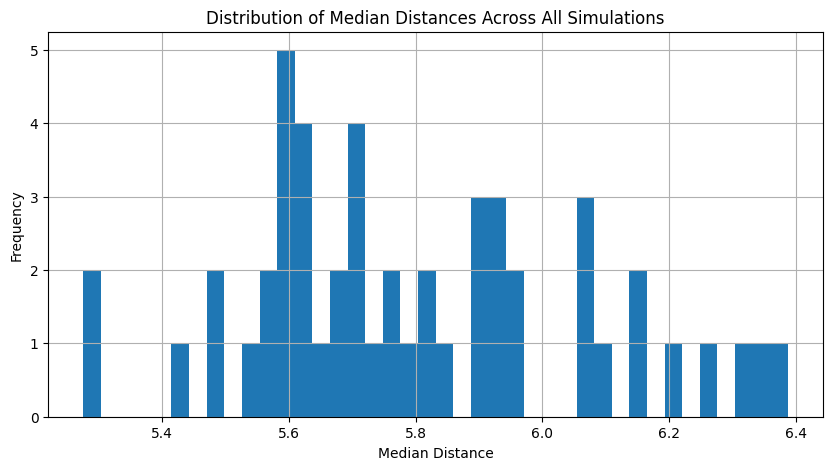

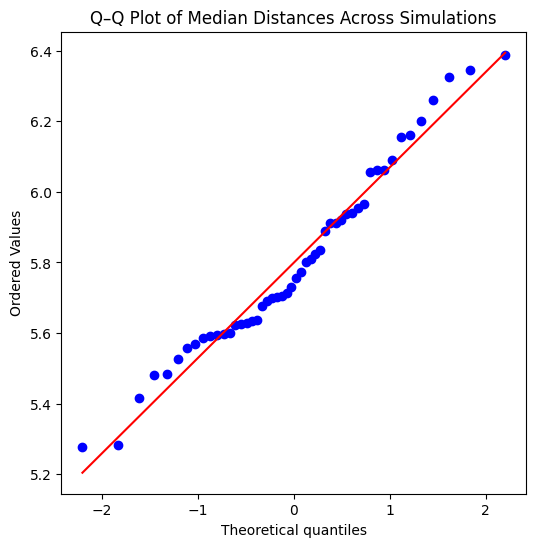

In [9]:
import scipy.stats as stats

plt.figure(figsize=(10, 5))
plt.hist(all_medians, bins=40)
plt.title('Distribution of Median Distances Across All Simulations')
plt.xlabel('Median Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(all_medians, dist="norm", plot=plt)
plt.title('Q–Q Plot of Median Distances Across Simulations')
plt.show()

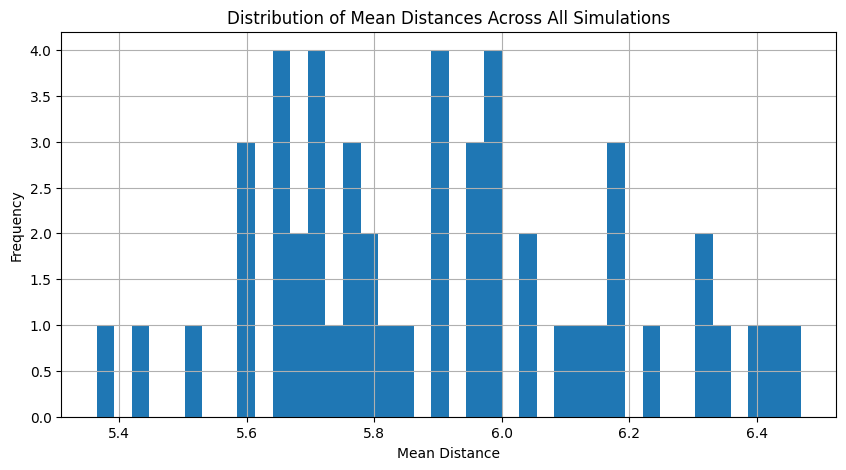

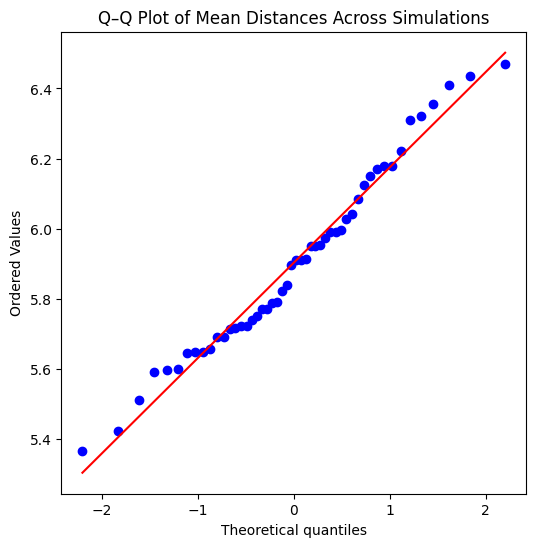

In [10]:
import scipy.stats as stats

plt.figure(figsize=(10, 5))
plt.hist(all_means, bins=40)
plt.title('Distribution of Mean Distances Across All Simulations')
plt.xlabel('Mean Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(all_means, dist="norm", plot=plt)
plt.title('Q–Q Plot of Mean Distances Across Simulations')
plt.show()

In [11]:
# Find the best KNN on overall data
X_train = data_train.drop(['y'], axis=1)
y_train = data_train['y']
X_test  = data_test.drop(['y'], axis=1)
y_test  = data_test['y']

params1 = {"n_neighbors": np.arange(3, 31, 2)}
knn   = KNeighborsClassifier()
model = GridSearchCV(knn, params1, scoring='f1_macro', cv=2, n_jobs=-1)
model.fit(X_train, y_train)
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)

buffer_model = {"dist_model": model, "prob_model": model}

R_star_global_model = compute_R_star(buffer_model, X_test)
k_global_model      = model.best_params_['n_neighbors']
V_global_model      = R_star_global_model / k_global_model

print(classification_report(y_test, y_pred))
print(f"Best Params: {model.best_params_}")

benchmark_f1      = f1_score(y_test, y_pred, average='macro')
benchmark_roc_auc = safe_roc_auc(y_test, y_proba)
benchmark_pr_auc  = multiclass_pr_auc(y_test, y_proba)
benchmark_brier   = multiclass_brier_score(y_test, y_proba)
benchmark_ece     = expected_calibration_error(y_test, y_proba)

print(f"Best F1 Score:   {benchmark_f1:.4f}")
print(f"ROC-AUC (macro): {benchmark_roc_auc:.4f}")
print(f"PR-AUC (macro):  {benchmark_pr_auc:.4f}")
print(f"Brier Score:     {benchmark_brier:.4f}")
print(f"ECE:             {benchmark_ece:.4f}")


              precision    recall  f1-score   support

           0       0.61      0.63      0.62      3698
           1       0.67      0.64      0.65      4231

    accuracy                           0.64      7929
   macro avg       0.64      0.64      0.64      7929
weighted avg       0.64      0.64      0.64      7929

Best Params: {'n_neighbors': np.int64(29)}
Best F1 Score:   0.6373
ROC-AUC (macro): 0.6843
PR-AUC (macro):  0.6610
Brier Score:     0.2251
ECE:             0.0352


In [12]:
# %%
# Analyze results
from scipy.stats import t as t_dist

approaches_labels = {
    'approach_1': 'Arctan ',
    'approach_2': 'Size   ',
    'approach_3': 'Tanh   ',
    'approach_4': 'Sigmoid',
    'approach_5': 'ReLU   ',
    'approach_6': 'W*     ',
}

metrics_info = [
    ('F1 (macro)',  '_f1',      False),
    ('Accuracy',   '_acc',     False),
    ('ROC-AUC',    '_roc_auc', False),
    ('PR-AUC',     '_pr_auc',  False),
    ('Brier Score','_brier',   True),
    ('ECE',        '_ece',     True),
]

print("Simulation Results Summary")
print("=" * 80)
print(f"Number of simulations: {len(results_df)}")

for metric_name, suffix, lower_better in metrics_info:
    direction = '(↓ better)' if lower_better else '(↑ better)'
    print(f"\nAverage {metric_name} {direction}:")
    print(f"  {'Approach':<10} {'Mean':>8}  {'Std':>8}  {'95% CI':>22}")
    print(f"  {'-'*10}  {'-'*8}  {'-'*8}  {'-'*22}")
    for key, label in approaches_labels.items():
        col       = f'{key}{suffix}'
        vals      = results_df[col].dropna()
        mean      = vals.mean()
        std       = vals.std()
        lo, hi    = ci_95(vals)
        print(f"  {label:<10} {mean:>8.4f}  {std:>8.4f}  [{lo:>8.4f}, {hi:>8.4f}]")


Simulation Results Summary
Number of simulations: 5

Average F1 (macro) (↑ better):
  Approach       Mean       Std                  95% CI
  ----------  --------  --------  ----------------------
  Arctan       0.6266    0.0203  [  0.6015,   0.6518]
  Size         0.6273    0.0215  [  0.6005,   0.6540]
  Tanh         0.6276    0.0223  [  0.5999,   0.6552]
  Sigmoid      0.6275    0.0222  [  0.6000,   0.6551]
  ReLU         0.6276    0.0209  [  0.6016,   0.6536]
  W*           0.6275    0.0201  [  0.6026,   0.6524]

Average Accuracy (↑ better):
  Approach       Mean       Std                  95% CI
  ----------  --------  --------  ----------------------
  Arctan       0.6312    0.0193  [  0.6072,   0.6552]
  Size         0.6316    0.0208  [  0.6058,   0.6574]
  Tanh         0.6320    0.0211  [  0.6058,   0.6582]
  Sigmoid      0.6320    0.0215  [  0.6053,   0.6587]
  ReLU         0.6320    0.0198  [  0.6074,   0.6566]
  W*           0.6320    0.0193  [  0.6081,   0.6559]

Average ROC

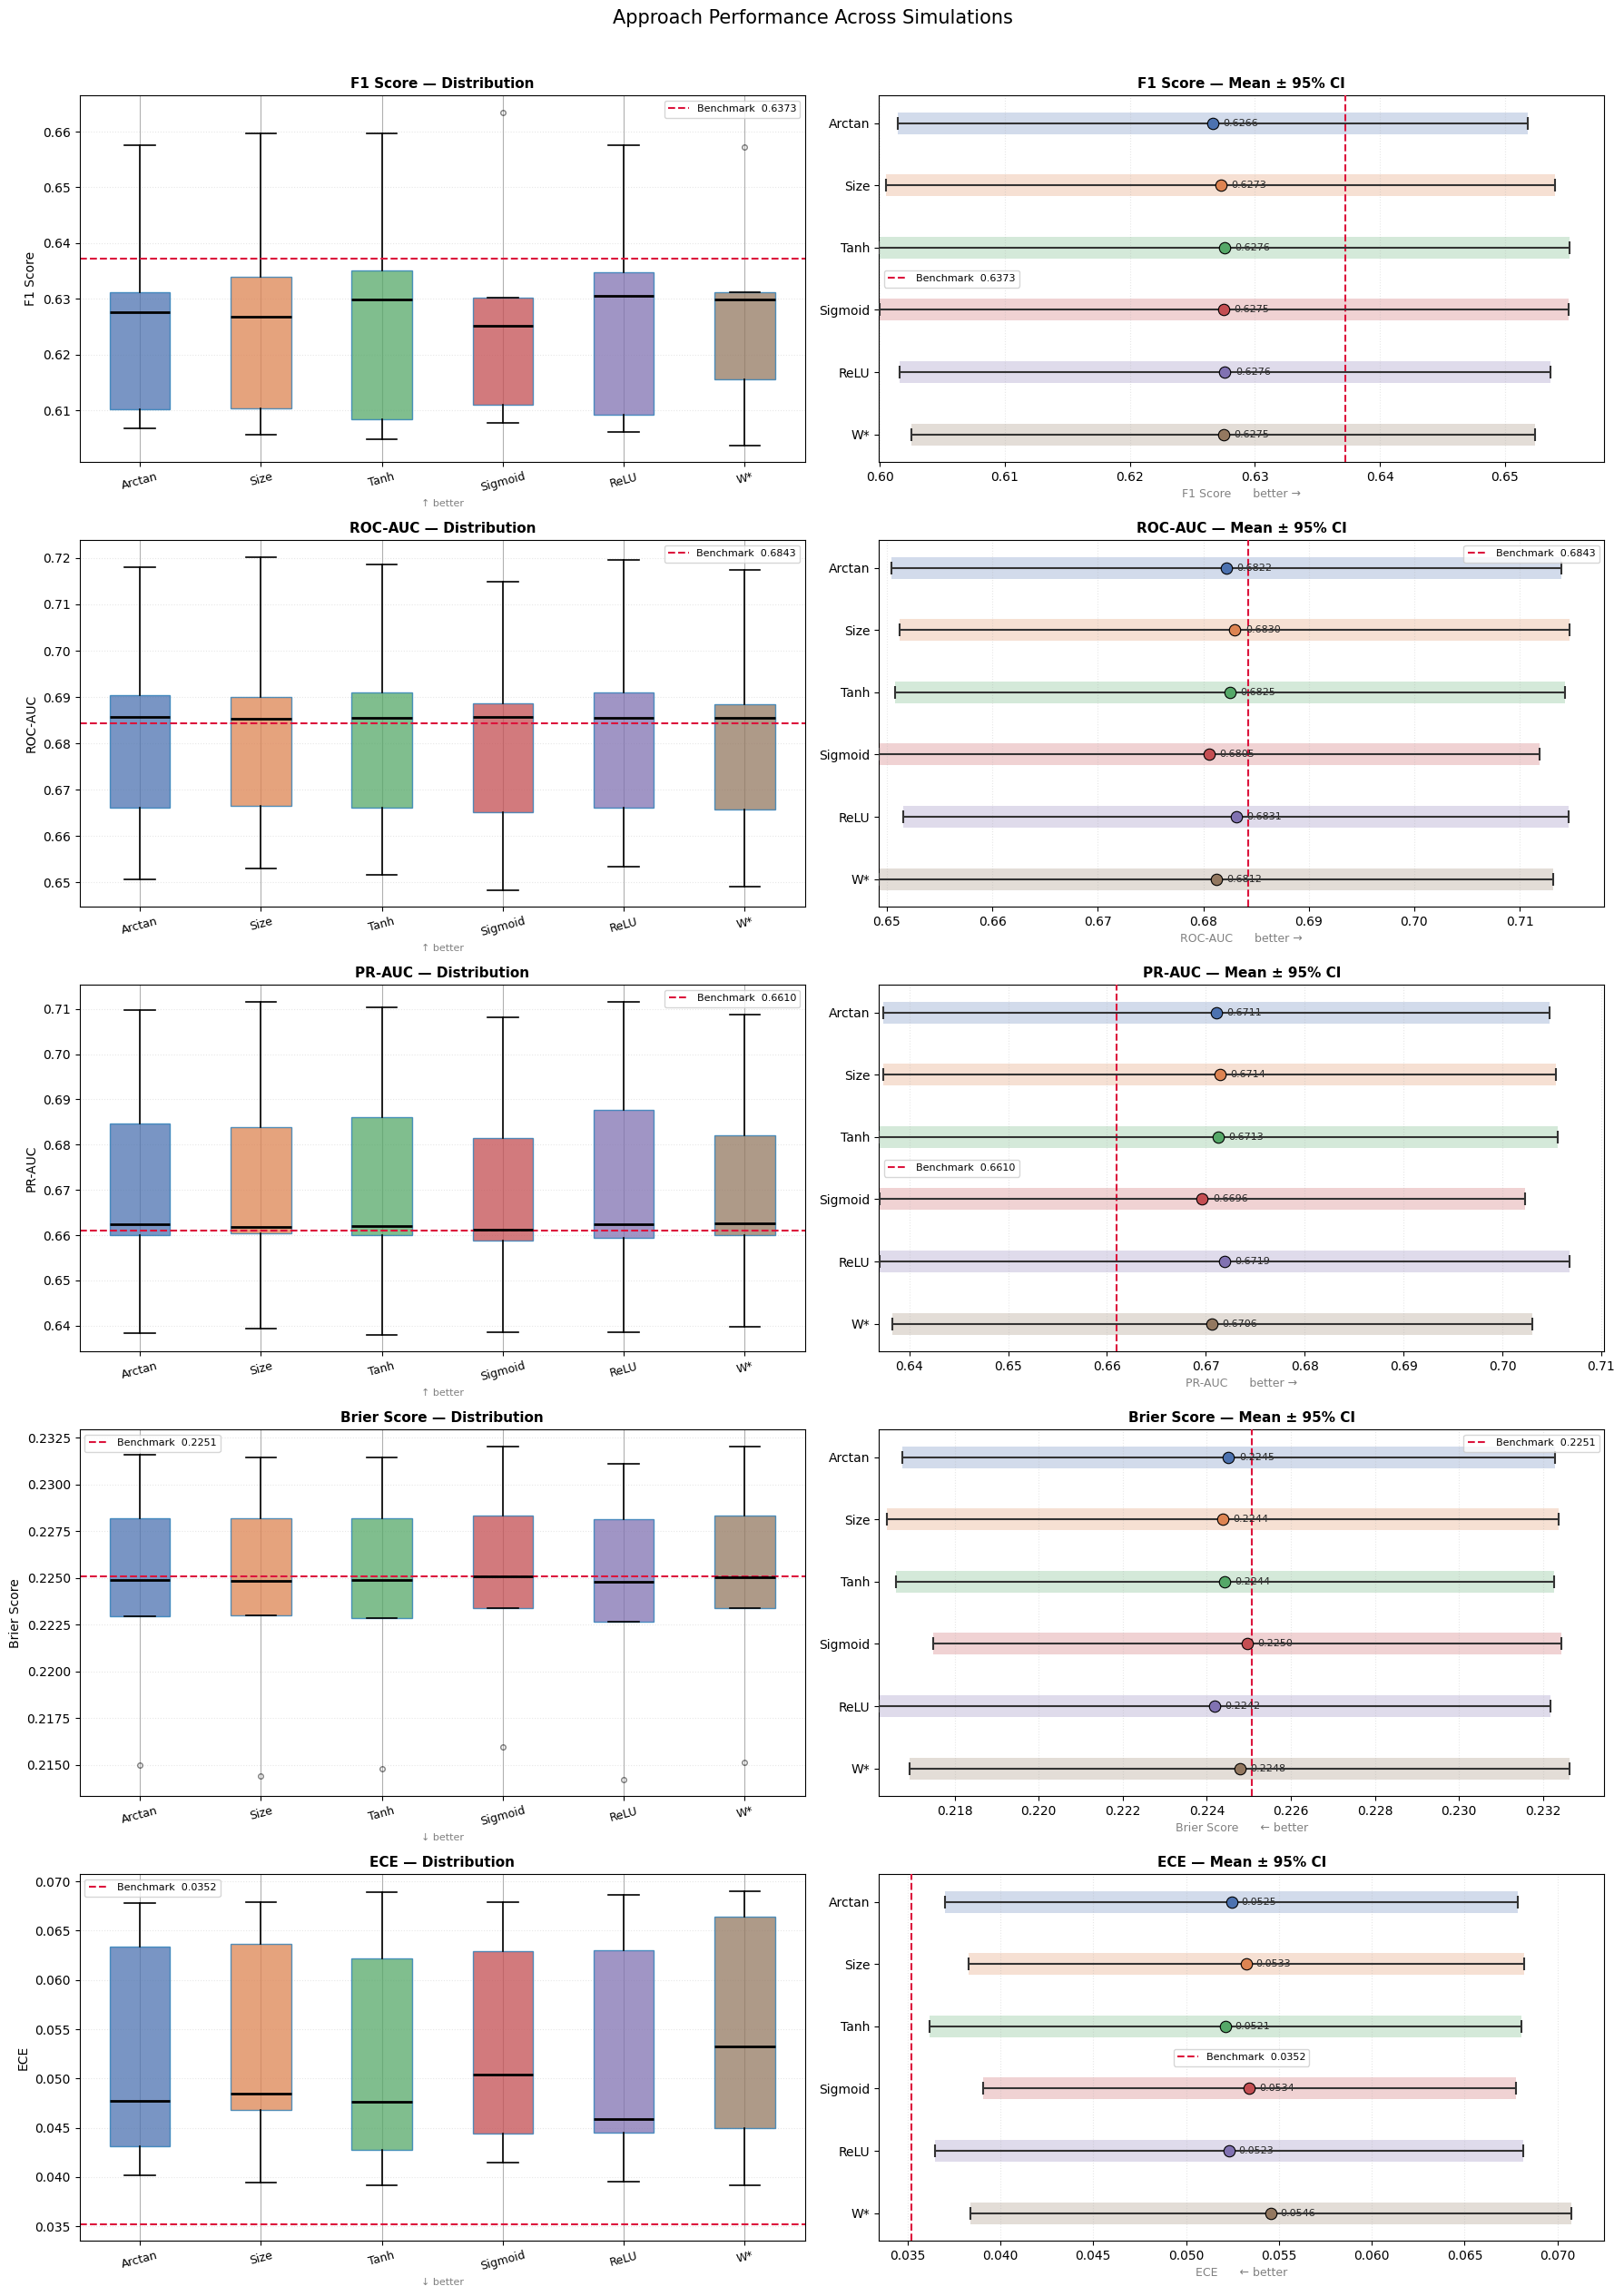

In [13]:
# %%
# Visualization — F1, ROC-AUC, PR-AUC, Brier Score, ECE
# Left:  boxplot across simulations
# Right: grouped mean ± 95% CI — one chart per metric, all approaches side-by-side
approach_labels = ['Arctan', 'Size', 'Tanh', 'Sigmoid', 'ReLU', 'W*']
colors          = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

plot_specs = [
    ('F1 Score',    '_f1',      benchmark_f1,      False),
    ('ROC-AUC',     '_roc_auc', benchmark_roc_auc, False),
    ('PR-AUC',      '_pr_auc',  benchmark_pr_auc,  False),
    ('Brier Score', '_brier',   benchmark_brier,   True),
    ('ECE',         '_ece',     benchmark_ece,     True),
]

fig, axes = plt.subplots(len(plot_specs), 2, figsize=(18, 5 * len(plot_specs)))
fig.suptitle('Approach Performance Across Simulations', fontsize=15, y=1.01)

for row, (metric_name, suffix, benchmark_val, lower_better) in enumerate(plot_specs):
    cols = [f'approach_{i}{suffix}' for i in range(1, 7)]

    # ── Left: boxplot ────────────────────────────────────────────────────────
    ax = axes[row, 0]
    bp = results_df[cols].boxplot(
        ax=ax, patch_artist=True, return_type='dict',
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
    )
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(f'{metric_name} — Distribution', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=10)
    ax.axhline(y=benchmark_val, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Benchmark  {benchmark_val:.4f}')
    ax.set_xticklabels(approach_labels, rotation=15, fontsize=9)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')
    ax.set_xlabel('↓ better' if lower_better else '↑ better', fontsize=8, color='grey')

    # ── Right: mean + 95% CI (horizontal lollipop chart) ────────────────────
    ax = axes[row, 1]
    means, lo_errs, hi_errs, ci_los, ci_his = [], [], [], [], []
    for col in cols:
        vals   = results_df[col].dropna()
        mean   = vals.mean()
        lo, hi = ci_95(vals)
        means.append(mean)
        lo_errs.append(mean - lo)
        hi_errs.append(hi - mean)
        ci_los.append(lo)
        ci_his.append(hi)

    y     = np.arange(len(approach_labels))
    means = np.array(means)

    # Horizontal CI spans
    for i, (lo, hi, color) in enumerate(zip(ci_los, ci_his, colors)):
        ax.barh(i, hi - lo, left=lo, height=0.35, color=color, alpha=0.25)

    # Mean dots
    for i, (mean, color) in enumerate(zip(means, colors)):
        ax.plot(mean, i, 'o', color=color, markersize=9, zorder=5,
                markeredgecolor='black', markeredgewidth=0.8)

    # CI whiskers
    ax.errorbar(means, y,
                xerr=[lo_errs, hi_errs],
                fmt='none', color='#333333', capsize=5,
                linewidth=1.5, capthick=1.5, zorder=4)

    # Benchmark line
    ax.axvline(x=benchmark_val, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Benchmark  {benchmark_val:.4f}', zorder=3)

    # Value labels on the dots
    x_range = max(ci_his) - min(ci_los)
    offset  = x_range * 0.015
    for i, mean in enumerate(means):
        ax.text(mean + offset, i, f'{mean:.4f}',
                va='center', ha='left', fontsize=8, color='#222222')

    ax.set_yticks(y)
    ax.set_yticklabels(approach_labels, fontsize=10)
    ax.set_xlabel(metric_name, fontsize=10)
    ax.set_title(f'{metric_name} — Mean ± 95% CI', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, axis='x', alpha=0.3, linestyle=':')
    ax.invert_yaxis()   # W* at top, Arctan at bottom — matches natural reading order
    direction_label = '← better' if lower_better else 'better →'
    ax.set_xlabel(f'{metric_name}      {direction_label}', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('approach_metrics_overview.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# %%
# Statistical significance testing
from scipy.stats import ttest_rel, t as t_dist

# ── Pairwise F1 t-tests ──────────────────────────────────────────────────────
pairs = [
    ('Arctan',  'approach_1', 'Size',    'approach_2'),
    ('Arctan',  'approach_1', 'Tanh',    'approach_3'),
    ('Size',    'approach_2', 'Tanh',    'approach_3'),
    ('Size',    'approach_2', 'Sigmoid', 'approach_4'),
    ('Tanh',    'approach_3', 'Sigmoid', 'approach_4'),
    ('Arctan',  'approach_1', 'Sigmoid', 'approach_4'),
]

print("Pairwise t-tests (F1 score):")
print(f"  {'Comparison':<22} {'p-value':>8}  {'95% CI on Δ':>26}")
print(f"  {'-'*22}  {'-'*8}  {'-'*26}")
for lA, kA, lB, kB in pairs:
    diff     = results_df[f'{kA}_f1'] - results_df[f'{kB}_f1']
    t, p     = ttest_rel(results_df[f'{kA}_f1'], results_df[f'{kB}_f1'])
    lo, hi   = ci_95(diff)
    label    = f'{lA} vs {lB}'
    print(f"  {label:<22} {p:>8.4f}  [{lo:>+9.4f}, {hi:>+9.4f}]")

# ── W* vs ReLU equivalence across all metrics ────────────────────────────────
metric_tests = [
    ('F1 Score',    '_f1',      False),
    ('ROC-AUC',     '_roc_auc', False),
    ('PR-AUC',      '_pr_auc',  False),
    ('Brier Score', '_brier',   True),
    ('ECE',         '_ece',     True),
]

print("\n── W* vs ReLU equivalence (paired t-test, two-tailed, α=0.05) ──")
print(f"{'Metric':<14} {'t-stat':>8}  {'p-value':>8}  {'Mean Δ':>9}  {'95% CI on Δ':>26}  {'Verdict'}")
print("-" * 85)
alpha     = 0.05
all_equiv = True
for metric_name, suffix, lower_better in metric_tests:
    col_wstar = f'approach_6{suffix}'
    col_relu  = f'approach_5{suffix}'
    diff      = results_df[col_wstar] - results_df[col_relu]
    t, p      = ttest_rel(results_df[col_wstar], results_df[col_relu])
    delta     = diff.mean()
    lo, hi    = ci_95(diff)
    equiv     = p > alpha
    if not equiv:
        all_equiv = False
    verdict = 'equivalent' if equiv else 'DIFFERENT'
    print(f"{metric_name:<14} {t:>8.4f}  {p:>8.4f}  {delta:>+9.4f}  [{lo:>+9.4f}, {hi:>+9.4f}]  {verdict}")

print()
if all_equiv:
    print("→ W* is statistically as good an approximation as ReLU on ALL metrics.")
else:
    print("→ W* and ReLU differ significantly on at least one metric.")


Pairwise t-tests (F1 score):
  Comparison              p-value                 95% CI on Δ
  ----------------------  --------  --------------------------
  Arctan vs Size           0.7855  [  -0.0067,   +0.0054]
  Arctan vs Tanh           0.4752  [  -0.0041,   +0.0023]
  Size vs Tanh             0.9150  [  -0.0071,   +0.0066]
  Size vs Sigmoid          0.8985  [  -0.0053,   +0.0048]
  Tanh vs Sigmoid          0.9908  [  -0.0069,   +0.0070]
  Arctan vs Sigmoid        0.6713  [  -0.0062,   +0.0045]

── W* vs ReLU equivalence (paired t-test, two-tailed, α=0.05) ──
Metric           t-stat   p-value     Mean Δ                 95% CI on Δ  Verdict
-------------------------------------------------------------------------------------
F1 Score        -0.0454    0.9660    -0.0001  [  -0.0073,   +0.0070]  equivalent
ROC-AUC         -2.3913    0.0751    -0.0019  [  -0.0040,   +0.0003]  equivalent
PR-AUC          -1.0278    0.3621    -0.0013  [  -0.0047,   +0.0022]  equivalent
Brier Score      3.54

## Theoretical Risk Analysis (Cover & Hart, 1967 + Dist-KNN)

The following cells compute the theoretical quantities from the Dist-KNN paper:

- **r\*(x)**: Conditional Bayes risk at point x — `min(q̂₁(x), q̂₂(x))` for binary classification  
- **R\***: Expected Bayes risk for each machine — `E[r*(x)]`  
- **Bᵢ(x)**: Local bias for machine i — `μ(x) − (1/Kᵢ) Σ μ(xᵢ,ⱼ)`  
- **C**: Uncentered covariance matrix where `C[i,j] = E[Bᵢ(x) Bⱼ(x)]`  
- **R**: Optimal aggregated risk under MSE — `R* + 1 / (1ᵀ (V+C)⁻¹ 1)`

In [15]:
# %%
# ─────────────────────────────────────────────────────────────────────────────
# Bootstrap KNN: Distance-Weighted Aggregation vs Standard Bagging
# ─────────────────────────────────────────────────────────────────────────────
#
# Your method  : Bootstrap samples → KNN per bag → aggregate via distance
#                weights (W*, ReLU, Arctan, Tanh, Sigmoid, Size) instead of
#                majority vote.
# Baseline     : sklearn BaggingClassifier(KNN) with majority vote,
#                hyperparameters chosen by cross-validation.
#
# Both use the same bootstrap protocol so the comparison is fair.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from scipy.stats import ttest_rel

# ── 0. Helpers ────────────────────────────────────────────────────────────────
def _bootstrap_knn_bags(X_train, y_train, n_estimators, k_per_bag, random_state=42):
    """
    Draw n_estimators bootstrap samples and fit a KNN on each.
    Returns list of (fitted_knn, oob_mask) tuples.
    Each bootstrap matches sklearn's protocol: sample n with replacement.
    """
    rng  = np.random.default_rng(random_state)
    n    = len(X_train)
    bags = []
    for _ in range(n_estimators):
        idx  = rng.integers(0, n, size=n)          # bootstrap indices
        knn  = KNeighborsClassifier(n_neighbors=k_per_bag, n_jobs=-1)
        knn.fit(X_train[idx], y_train[idx])
        bags.append(knn)
    return bags


def _aggregate_distance_weighted(bags, X_train, y_train, X_test,
                                 weight_fn, n_classes):
    """
    For each bag, compute a distance-based scalar weight and return the
    weighted-average probability matrix (n_test, n_classes).

    weight_fn(median_dist, all_median_dists) → scalar weight ≥ 0
    """
    # Per-bag: median distance to training set (proxy for 'closeness')
    median_dists = []
    for knn in bags:
        dists, _ = knn.kneighbors(X_test)          # (n_test, k)
        median_dists.append(np.median(dists))       # one scalar per bag

    median_dists = np.array(median_dists)           # (M,)
    weights      = np.array([weight_fn(d, median_dists) for d in median_dists])
    weights      = np.clip(weights, 0, None)

    if weights.sum() == 0:
        weights = np.ones(len(bags))
    weights = weights / weights.sum()

    # Weighted probability
    proba_stack = np.stack(
        [knn.predict_proba(X_test) for knn in bags], axis=0
    )   # (M, n_test, n_classes)

    weighted_proba = (proba_stack * weights[:, None, None]).sum(axis=0)
    return weighted_proba                           # (n_test, n_classes)


def _wstar_aggregate(bags, X_test, R_star_list, K_list):
    """
    Optimal W* aggregation matching the simulation's Sherman-Morrison formula.
    Returns (weighted_proba, W_star).
    """
    M           = len(bags)
    R_star_vec  = np.array(R_star_list)
    K_vec       = np.array(K_list, dtype=float)

    # Simplified W* (no bias term b — b requires full training set access;
    # use the V-only closed form: w*_i ∝ K_i / R*_i )
    raw         = K_vec / (R_star_vec + 1e-10)
    W_star      = raw / raw.sum()

    proba_stack = np.stack(
        [knn.predict_proba(X_test) for knn in bags], axis=0
    )   # (M, n_test, n_classes)
    weighted_proba = (proba_stack * W_star[:, None, None]).sum(axis=0)
    return weighted_proba, W_star


def _compute_all_metrics(y_true, y_proba):
    y_pred = np.argmax(y_proba, axis=1)
    return {
        'f1'      : f1_score(y_true, y_pred, average='macro'),
        'acc'     : accuracy_score(y_true, y_pred),
        'roc_auc' : safe_roc_auc(y_true, y_proba),
        'pr_auc'  : multiclass_pr_auc(y_true, y_proba),
        'brier'   : multiclass_brier_score(y_true, y_proba),
        'ece'     : expected_calibration_error(y_true, y_proba),
    }


# ── 1. Cross-validate BaggingClassifier hyperparameters on the training set ──
print("Cross-validating BaggingClassifier hyperparameters ...")
X_tr = data_train.drop('y', axis=1).values
y_tr = data_train['y'].values
X_te = data_test.drop('y', axis=1).values
y_te = data_test['y'].values
n_classes = len(np.unique(y_tr))

param_grid = {
    'n_estimators' : [10, 20, 50],
    'estimator__n_neighbors': [3, 7, 15],
}
bag_base = BaggingClassifier(
    estimator=KNeighborsClassifier(),
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)
cv_bag = GridSearchCV(
    bag_base, param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1, verbose=0,
)
cv_bag.fit(X_tr, y_tr)
best_n_est = cv_bag.best_params_['n_estimators']
best_k     = cv_bag.best_params_['estimator__n_neighbors']
print(f"  Best params: n_estimators={best_n_est}, k={best_k}")


# ── 2. Simulation loop ────────────────────────────────────────────────────────
N_SIMS      = 10
bagging_records = []

# Weight functions (matching cell 6 definitions exactly)
def _arctan_w(d, all_d):
    lo, hi = all_d.min(), all_d.max()
    return 0.5 + np.arctan(((hi + lo) / 2) - d) / np.pi

def _tanh_w(d, all_d):
    lo, hi = all_d.min(), all_d.max()
    return 0.5 + 0.5 * np.tanh(((hi + lo) / 2) - d)

def _sigmoid_w(d, all_d):
    lo, hi = all_d.min(), all_d.max()
    return 1 / (1 + 2 * np.exp(((hi + lo) / 2) - d))

def _relu_w(d, all_d):
    mu, sigma = all_d.mean(), all_d.std()
    upper, lower = mu + 2 * sigma, mu - 2 * sigma
    if d > upper or d < lower:
        return 0.0
    return upper - d

def _size_w(d, all_d):       # uniform — dataset_size not available per-bag
    return 1.0               # equivalent to unweighted average

weight_fns = {
    'arctan'  : _arctan_w,
    'tanh'    : _tanh_w,
    'sigmoid' : _sigmoid_w,
    'relu'    : _relu_w,
    'size'    : _size_w,
}

print(f"\nRunning {N_SIMS} simulations ...")
for sim in range(N_SIMS):
    print(f"  Simulation {sim + 1}/{N_SIMS}", end='\r')
    rng = np.random.default_rng(sim)

    # Sub-sample test set (match simulation cell: up to 500 points)
    n_test   = min(500, len(X_te))
    test_idx = rng.choice(len(X_te), size=n_test, replace=False)
    Xq, yq   = X_te[test_idx], y_te[test_idx]

    # ── Standard BaggingClassifier (majority vote) ────────────────────────
    bag_clf = BaggingClassifier(
        estimator=KNeighborsClassifier(n_neighbors=best_k),
        n_estimators=best_n_est,
        bootstrap=True,
        random_state=sim,
        n_jobs=-1,
    )
    bag_clf.fit(X_tr, y_tr)
    # BaggingClassifier.predict_proba = average of member probas
    bag_proba = bag_clf.predict_proba(Xq)
    bag_metrics = _compute_all_metrics(yq, bag_proba)

    # ── Your method: same bootstrap bags, distance-weighted aggregation ───
    bags = _bootstrap_knn_bags(X_tr, y_tr, best_n_est, best_k, random_state=sim)

    rec = {'simulation': sim}
    for suffix, (name, fn) in enumerate(weight_fns.items()):
        wp = _aggregate_distance_weighted(bags, X_tr, y_tr, Xq, fn, n_classes)
        m  = _compute_all_metrics(yq, wp)
        for metric, val in m.items():
            rec[f'{name}_{metric}'] = val

    # W* aggregation
    # R*(x) = 1 - max_c proba_c  for each bag
    R_star_list = []
    for knn in bags:
        p = knn.predict_proba(Xq)
        R_star_list.append(float((1 - p.max(axis=1)).mean()))
    K_list = [best_k] * len(bags)
    wp_wstar, W_star = _wstar_aggregate(bags, Xq, R_star_list, K_list)
    m_wstar = _compute_all_metrics(yq, wp_wstar)
    for metric, val in m_wstar.items():
        rec[f'wstar_{metric}'] = val

    # Bagging baseline
    for metric, val in bag_metrics.items():
        rec[f'bagging_{metric}'] = val

    bagging_records.append(rec)

print("\nDone.")
bag_results_df = pd.DataFrame(bagging_records)
print(bag_results_df.head())


Cross-validating BaggingClassifier hyperparameters ...
  Best params: n_estimators=50, k=15

Running 10 simulations ...
  Simulation 10/10
Done.
   simulation  arctan_f1  arctan_acc  arctan_roc_auc  arctan_pr_auc  \
0           0   0.620541       0.622        0.660040       0.651543   
1           1   0.628751       0.630        0.660650       0.648702   
2           2   0.613875       0.614        0.659512       0.645487   
3           3   0.632000       0.632        0.699813       0.687317   
4           4   0.587974       0.588        0.648061       0.645164   

   arctan_brier  arctan_ece   tanh_f1  tanh_acc  tanh_roc_auc  ...  \
0      0.236107    0.063811  0.620541     0.622      0.660040  ...   
1      0.233245    0.060882  0.628751     0.630      0.660650  ...   
2      0.234646    0.067734  0.613875     0.614      0.659512  ...   
3      0.220908    0.052880  0.632000     0.632      0.699813  ...   
4      0.238248    0.087329  0.587974     0.588      0.648061  ...   

   wsta

In [16]:
# %%
# ── Summary: Distance-Weighted Bootstrap KNN vs Standard Bagging ──────────────

approach_map = {
    'arctan'  : 'Arctan  ',
    'tanh'    : 'Tanh    ',
    'sigmoid' : 'Sigmoid ',
    'relu'    : 'ReLU    ',
    'size'    : 'Uniform ',
    'wstar'   : 'W*      ',
    'bagging' : 'Bagging ✓',
}

metric_map = [
    ('F1 (macro)',  'f1',      False),
    ('Accuracy',    'acc',     False),
    ('ROC-AUC',     'roc_auc', False),
    ('PR-AUC',      'pr_auc',  False),
    ('Brier Score', 'brier',   True),
    ('ECE',         'ece',     True),
]

print("Bootstrap KNN — Distance Aggregation vs Standard Bagging")
print("=" * 85)
print(f"Simulations: {len(bag_results_df)}  |  "      f"n_estimators={best_n_est}  |  k={best_k}")

for metric_name, suffix, lower_better in metric_map:
    direction = '(↓ better)' if lower_better else '(↑ better)'
    print(f"\n{metric_name} {direction}:")
    print(f"  {'Method':<14} {'Mean':>8}  {'Std':>8}  {'95% CI':>24}")
    print(f"  {'-'*14}  {'-'*8}  {'-'*8}  {'-'*24}")
    for key, label in approach_map.items():
        col  = f'{key}_{suffix}'
        vals = bag_results_df[col].dropna()
        mean = vals.mean()
        std  = vals.std()
        lo, hi = ci_95(vals)
        star = ' ←' if key == 'bagging' else ''
        print(f"  {label:<14} {mean:>8.4f}  {std:>8.4f}  [{lo:>8.4f}, {hi:>8.4f}]{star}")


Bootstrap KNN — Distance Aggregation vs Standard Bagging
Simulations: 10  |  n_estimators=50  |  k=15

F1 (macro) (↑ better):
  Method             Mean       Std                    95% CI
  --------------  --------  --------  ------------------------
  Arctan           0.6203    0.0161  [  0.6088,   0.6318]
  Tanh             0.6203    0.0161  [  0.6088,   0.6318]
  Sigmoid          0.6203    0.0163  [  0.6087,   0.6319]
  ReLU             0.6191    0.0163  [  0.6074,   0.6308]
  Uniform          0.6203    0.0160  [  0.6089,   0.6318]
  W*               0.6205    0.0162  [  0.6090,   0.6321]
  Bagging ✓        0.6213    0.0182  [  0.6083,   0.6344] ←

Accuracy (↑ better):
  Method             Mean       Std                    95% CI
  --------------  --------  --------  ------------------------
  Arctan           0.6216    0.0163  [  0.6100,   0.6332]
  Tanh             0.6216    0.0163  [  0.6100,   0.6332]
  Sigmoid          0.6216    0.0164  [  0.6098,   0.6334]
  ReLU             0

In [17]:
# %%
# ── Paired t-tests: each distance method vs Standard Bagging ─────────────────
from scipy.stats import ttest_rel

dist_methods = ['arctan', 'tanh', 'sigmoid', 'relu', 'size', 'wstar']
method_labels = {
    'arctan' : 'Arctan  ', 'tanh'   : 'Tanh    ',
    'sigmoid': 'Sigmoid ', 'relu'   : 'ReLU    ',
    'size'   : 'Uniform ', 'wstar'  : 'W*      ',
}
metric_tests = [
    ('F1',      'f1',      False),
    ('ROC-AUC', 'roc_auc', False),
    ('PR-AUC',  'pr_auc',  False),
    ('Brier',   'brier',   True),
    ('ECE',     'ece',     True),
]
alpha = 0.05

for metric_name, suffix, lower_better in metric_tests:
    print(f"\n── {metric_name} vs Bagging (paired t-test, two-tailed, α={alpha}) ──")
    direction = '(↓ better → negative Δ wins)' if lower_better else '(↑ better → positive Δ wins)'
    print(f"   Δ = method − Bagging  {direction}")
    print(f"  {'Method':<14} {'t':>7}  {'p':>7}  {'Mean Δ':>9}  {'95% CI on Δ':>26}  Verdict")
    print(f"  {'-'*14}  {'-'*7}  {'-'*7}  {'-'*9}  {'-'*26}  -------")
    for key in dist_methods:
        col_m   = f'{key}_{suffix}'
        col_bag = f'bagging_{suffix}'
        diff    = bag_results_df[col_m] - bag_results_df[col_bag]
        t, p    = ttest_rel(bag_results_df[col_m], bag_results_df[col_bag])
        delta   = diff.mean()
        lo, hi  = ci_95(diff)
        if lower_better:
            verdict = 'BETTER' if (p < alpha and delta < 0) else ('WORSE' if (p < alpha and delta > 0) else 'equiv')
        else:
            verdict = 'BETTER' if (p < alpha and delta > 0) else ('WORSE' if (p < alpha and delta < 0) else 'equiv')
        label = method_labels[key]
        print(f"  {label:<14} {t:>7.3f}  {p:>7.4f}  {delta:>+9.4f}  [{lo:>+9.4f}, {hi:>+9.4f}]  {verdict}")



── F1 vs Bagging (paired t-test, two-tailed, α=0.05) ──
   Δ = method − Bagging  (↑ better → positive Δ wins)
  Method               t        p     Mean Δ                 95% CI on Δ  Verdict
  --------------  -------  -------  ---------  --------------------------  -------
  Arctan          -0.477   0.6445    -0.0010  [  -0.0059,   +0.0039]  equiv
  Tanh            -0.477   0.6445    -0.0010  [  -0.0059,   +0.0039]  equiv
  Sigmoid         -0.441   0.6697    -0.0010  [  -0.0063,   +0.0042]  equiv
  ReLU            -0.727   0.4860    -0.0022  [  -0.0092,   +0.0047]  equiv
  Uniform         -0.449   0.6640    -0.0010  [  -0.0060,   +0.0040]  equiv
  W*              -0.365   0.7234    -0.0008  [  -0.0057,   +0.0041]  equiv

── ROC-AUC vs Bagging (paired t-test, two-tailed, α=0.05) ──
   Δ = method − Bagging  (↑ better → positive Δ wins)
  Method               t        p     Mean Δ                 95% CI on Δ  Verdict
  --------------  -------  -------  ---------  -----------------------

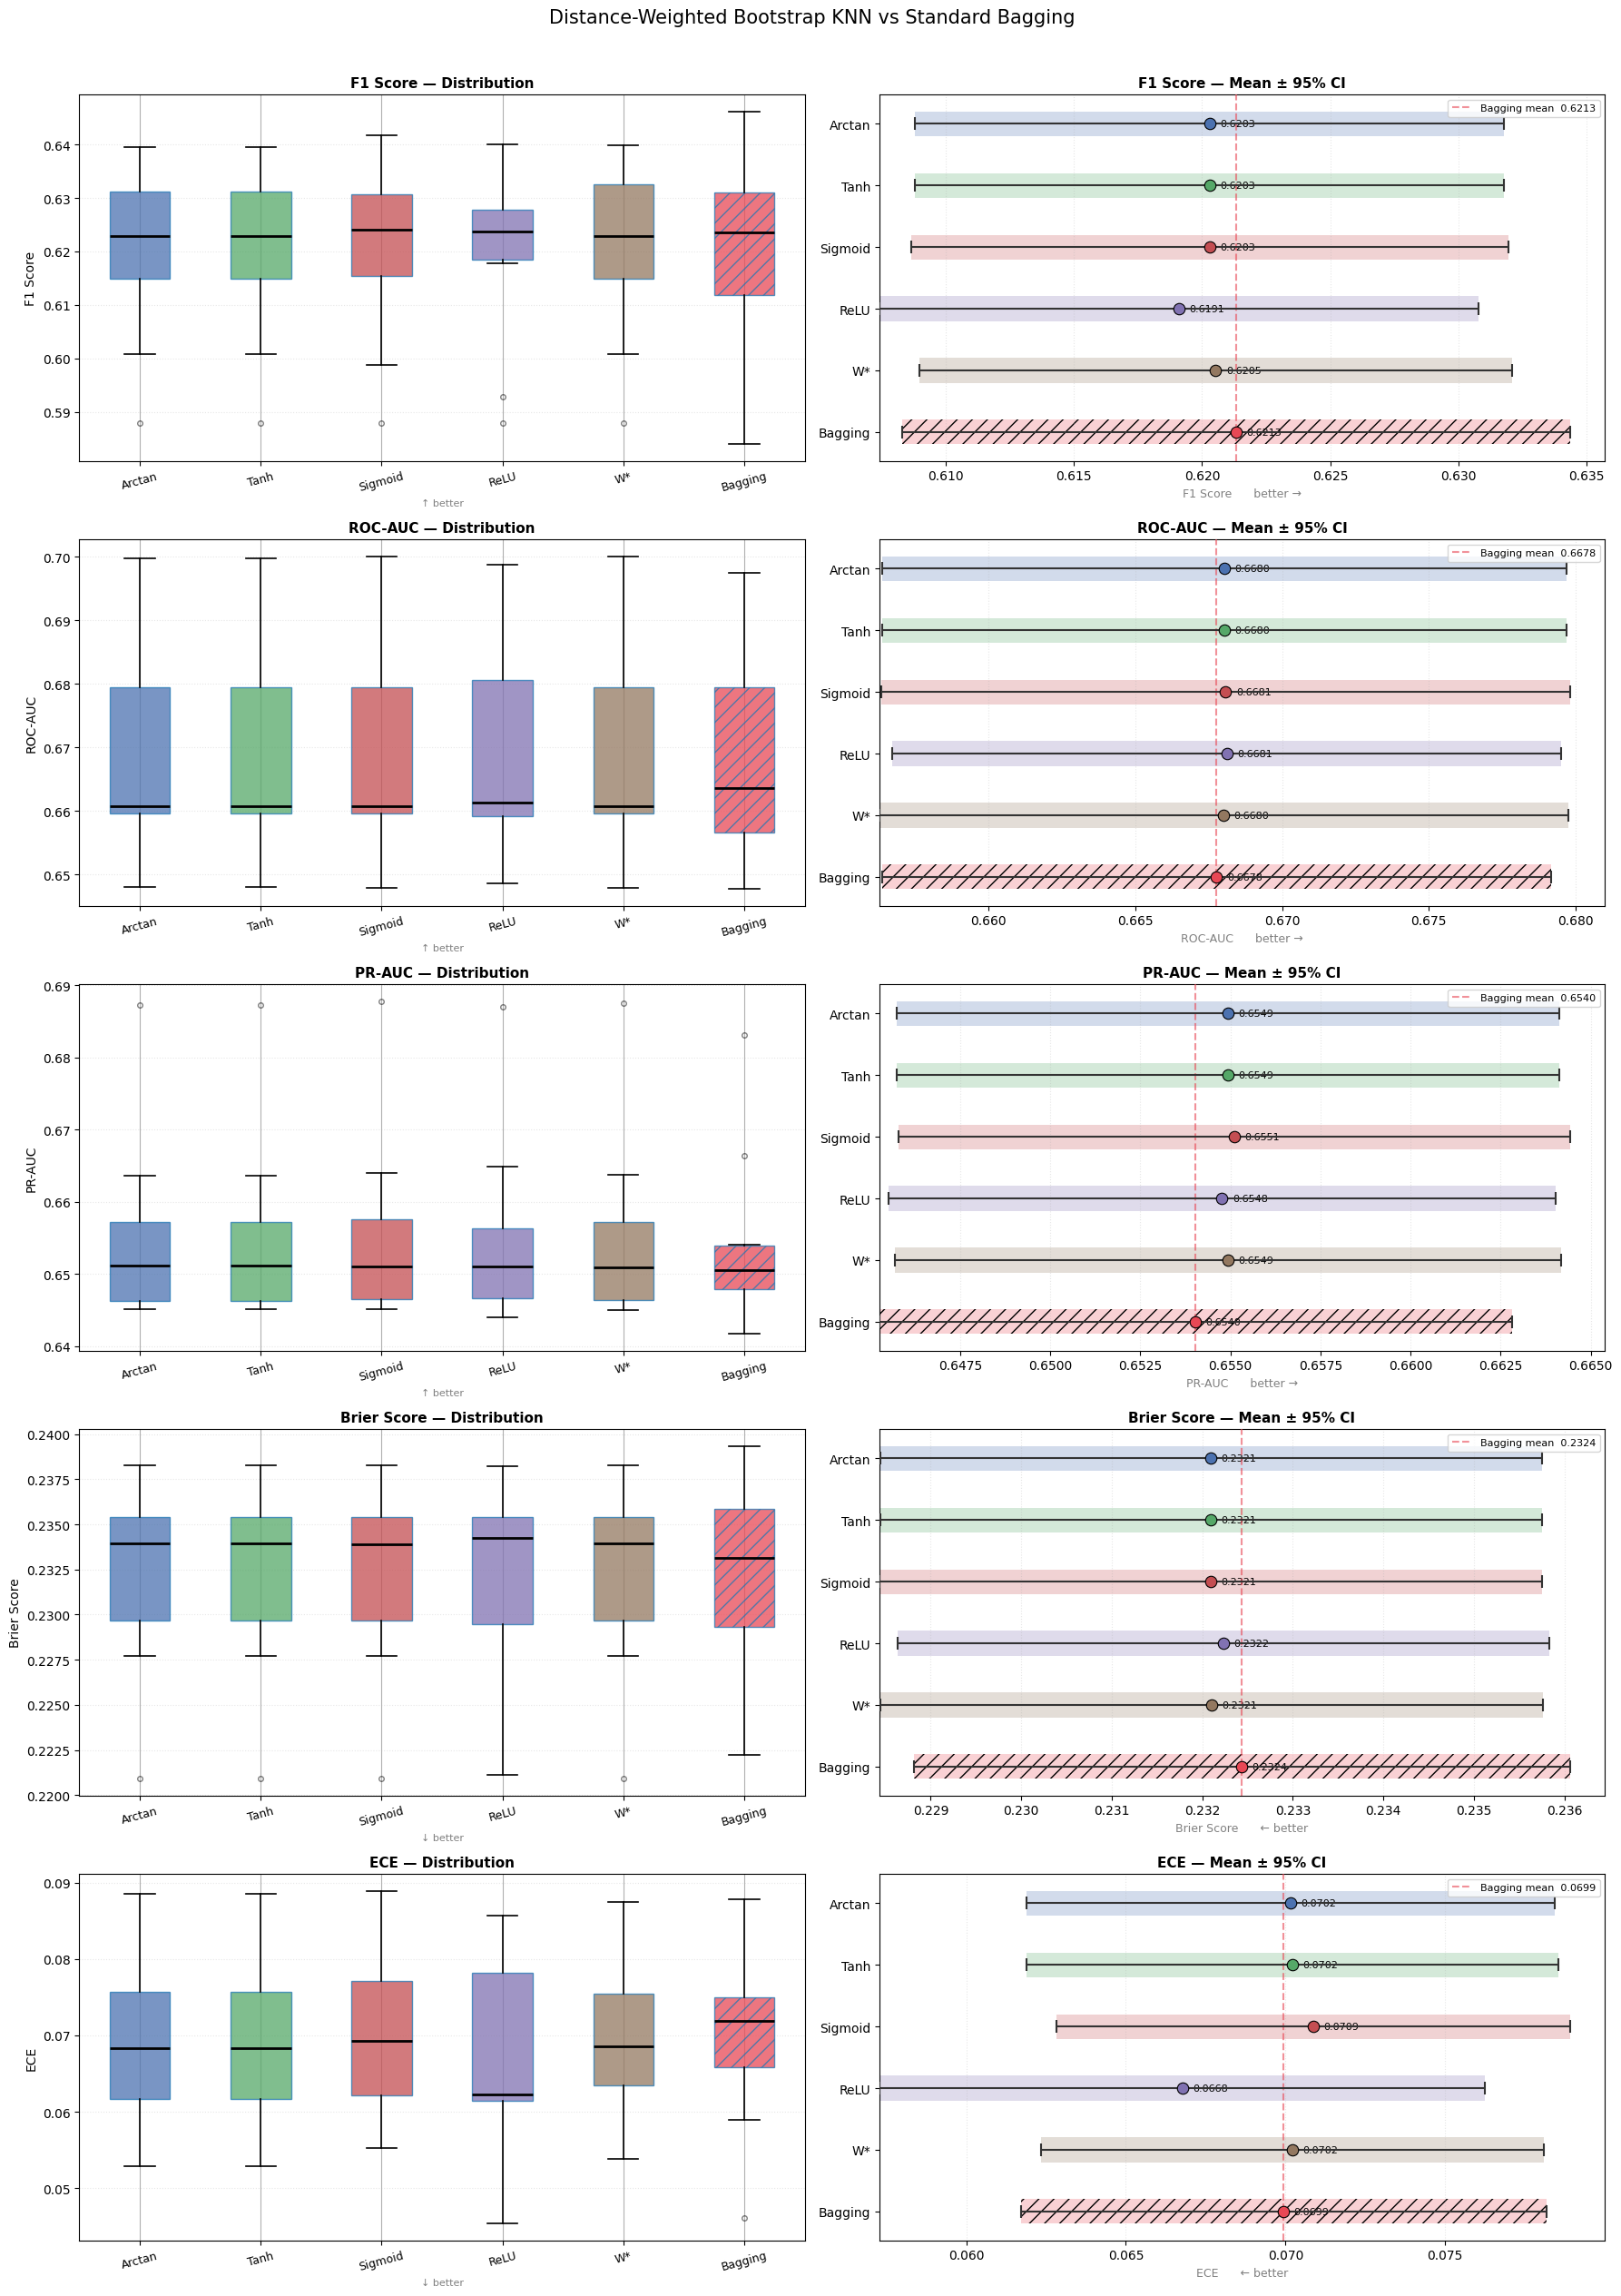

In [18]:
# %%
# ── Visualisation: Distance-Weighted Bootstrap KNN vs Bagging ─────────────────
dist_keys    = ['arctan', 'tanh', 'sigmoid', 'relu', 'wstar', 'bagging']
dist_labels  = ['Arctan', 'Tanh', 'Sigmoid', 'ReLU', 'W*', 'Bagging']
dist_colors  = ['#4C72B0','#55A868','#C44E52','#8172B2','#937860','#E84855']
hatch_list   = ['', '', '', '', '', '//']   # hatch Bagging bar to distinguish

plot_metrics = [
    ('F1 Score',    'f1',      False),
    ('ROC-AUC',     'roc_auc', False),
    ('PR-AUC',      'pr_auc',  False),
    ('Brier Score', 'brier',   True),
    ('ECE',         'ece',     True),
]

fig, axes = plt.subplots(len(plot_metrics), 2, figsize=(18, 5 * len(plot_metrics)))
fig.suptitle('Distance-Weighted Bootstrap KNN vs Standard Bagging', fontsize=15, y=1.01)

for row, (metric_name, suffix, lower_better) in enumerate(plot_metrics):
    cols = [f'{k}_{suffix}' for k in dist_keys]

    # ── Left: boxplot ────────────────────────────────────────────────────────
    ax = axes[row, 0]
    bp = bag_results_df[cols].boxplot(
        ax=ax, patch_artist=True, return_type='dict',
        medianprops=dict(color='black', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
    )
    for patch, color, hatch in zip(bp['boxes'], dist_colors, hatch_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_hatch(hatch)
    ax.set_xticklabels(dist_labels, rotation=15, fontsize=9)
    ax.set_title(f'{metric_name} — Distribution', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric_name)
    ax.grid(True, axis='y', alpha=0.3, linestyle=':')
    ax.set_xlabel('↓ better' if lower_better else '↑ better', fontsize=8, color='grey')

    # ── Right: horizontal lollipop — mean ± 95% CI ──────────────────────────
    ax = axes[row, 1]
    means, ci_los, ci_his = [], [], []
    for col in cols:
        vals   = bag_results_df[col].dropna()
        mean   = vals.mean()
        lo, hi = ci_95(vals)
        means.append(mean)
        ci_los.append(lo)
        ci_his.append(hi)

    means  = np.array(means)
    y      = np.arange(len(dist_labels))

    for i, (lo, hi, color, hatch) in enumerate(zip(ci_los, ci_his, dist_colors, hatch_list)):
        ax.barh(i, hi - lo, left=lo, height=0.4,
                color=color, alpha=0.25, hatch=hatch)

    for i, (mean, color) in enumerate(zip(means, dist_colors)):
        ax.plot(mean, i, 'o', color=color, markersize=9, zorder=5,
                markeredgecolor='black', markeredgewidth=0.8)

    lo_errs = means - np.array(ci_los)
    hi_errs = np.array(ci_his) - means
    ax.errorbar(means, y, xerr=[lo_errs, hi_errs],
                fmt='none', color='#333333', capsize=5,
                linewidth=1.5, capthick=1.5, zorder=4)

    x_range = max(ci_his) - min(ci_los)
    offset  = x_range * 0.015
    for i, mean in enumerate(means):
        ax.text(mean + offset, i, f'{mean:.4f}',
                va='center', ha='left', fontsize=8)

    ax.set_yticks(y)
    ax.set_yticklabels(dist_labels, fontsize=10)
    ax.set_title(f'{metric_name} — Mean ± 95% CI', fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3, linestyle=':')
    ax.invert_yaxis()
    direction_label = '← better' if lower_better else 'better →'
    ax.set_xlabel(f'{metric_name}      {direction_label}', fontsize=9, color='grey')

    # Shade bagging mean as a vertical reference line
    bag_mean = bag_results_df[f'bagging_{suffix}'].mean()
    ax.axvline(x=bag_mean, color='#E84855', linestyle='--', linewidth=1.5,
               alpha=0.6, label=f'Bagging mean  {bag_mean:.4f}', zorder=3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('bagging_vs_distance_weighted.png', dpi=150, bbox_inches='tight')
plt.show()
